# Module 02 · Nền tảng: biến đổi, điều kiện tồn tại và đối xứng

**Nguồn sách:** Bracewell, chương 2, tr. 5–23

Notebook đi kèm bài giảng cùng số module. Chạy lần lượt từng cell; sau mỗi cell có phần **📤 Đầu ra thật** giải thích con số.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """Phổ biên độ một phía: sóng hình sin biên độ A cho vạch A, thành phần một chiều cho đúng giá trị của nó"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """In một kết quả có tên, bỏ các số 0 thừa ở cuối (trang web đọc các dòng bắt đầu bằng ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Cặp biến đổi và định lý tích phân Fourier
🎯 **Phương pháp này trả lời câu hỏi gì?** Các biến đổi quen thuộc (Gauss, sech, $\Pi$, $\Lambda$, hàm nhân quả) có đúng như công thức đóng không, hai lần biến đổi có trả về $f(-x)$ không, và biến đổi ngược thu lại gì ở chỗ gián đoạn? Ta so tích phân số với công thức, và DFT với ma trận DFT dựng tay.

In [2]:
from scipy import integrate, special
from scipy.signal import lfilter
trap = getattr(np, "trapezoid", None) or np.trapz

def ft_support(f, a, b, s, pts=None):
    """Biến đổi Fourier (hệ 1) của f trên [a, b] bằng tích phân số"""
    re = integrate.quad(lambda x: f(x)*np.cos(2*np.pi*x*s), a, b, points=pts, limit=400)[0]
    im = integrate.quad(lambda x: -f(x)*np.sin(2*np.pi*x*s), a, b, points=pts, limit=400)[0]
    return re + 1j*im

gauss = lambda x: np.exp(-np.pi*x**2)
sech = lambda x: 1/np.cosh(np.pi*x)
for s in (0.0, 0.5, 1.0):
    assert abs(ft_support(gauss, -40, 40, s) - np.exp(-np.pi*s**2)) < 1e-8
    assert abs(ft_support(sech, -40, 40, s) - 1/np.cosh(np.pi*s)) < 1e-8
report("gauss_05", ft_support(gauss, -40, 40, 0.5).real, ".4f")
report("sech_05", ft_support(sech, -40, 40, 0.5).real, ".4f")

pi05 = ft_support(lambda x: 1.0, -0.5, 0.5, 0.5); pi2 = ft_support(lambda x: 1.0, -0.5, 0.5, 2.0)
assert abs(pi05 - np.sinc(0.5)) < 1e-9 and abs(pi2) < 1e-9
report("pi_05", pi05.real, ".4f"); report("pi_2", abs(pi2), ".4f")
tri05 = ft_support(lambda x: 1 - abs(x), -1, 1, 0.5, [0])
assert abs(tri05 - np.sinc(0.5)**2) < 1e-9
report("tri_05", tri05.real, ".4f")
ea = ft_support(lambda x: np.exp(-abs(x)), -40, 40, 0.25, [0]).real
assert abs(ea - 2/(1 + 4*np.pi**2*0.25**2)) < 1e-8
report("expabs_025", ea, ".4f")
Fc1 = ft_support(lambda x: np.exp(-x), 0, 40, 0.1)               # hàm nhân quả e^{-x}H(x)
assert abs(Fc1 - 1/(1 + 2j*np.pi*0.1)) < 1e-8
report("causal_mag_01", abs(Fc1), ".4f"); report("causal_ph_01", np.degrees(np.angle(Fc1)), ".2f")

# Tính tuần hoàn: F F f = f(−x). Cách A: FFT; cách B: ma trận DFT dựng tay
N = 64; nn = np.arange(N)
v = np.sin(nn**1.5) + 0.2*nn/N                                   # dãy không chẵn không lẻ
W = np.exp(-2j*np.pi*np.outer(nn, nn)/N)
rev = v[(-nn) % N]
ffA = np.fft.fft(np.fft.fft(v))/N; ffB = (W @ (W @ v))/N
assert np.allclose(ffA, rev) and np.allclose(ffB, rev)
f4 = np.fft.fft(np.fft.fft(np.fft.fft(np.fft.fft(v))))/N**2
assert np.allclose(f4, v)
report("cyc_err", max(np.max(np.abs(ffA - rev)), np.max(np.abs(ffB - rev))), ".1e"); report("cyc4_err", np.max(np.abs(f4 - v)), ".1e")

# Định lý tích phân Fourier tại điểm nhảy của Π: cắt biến đổi ngược ở |s| ≤ S
def inv_num(x, S):      # cách A: tích phân số dao động
    return 2*integrate.quad(np.sinc, 0, S, weight="cos", wvar=2*np.pi*x, limit=2000)[0]
def inv_si(x, S):       # cách B: công thức đóng qua hàm Si
    return (special.sici(np.pi*S*(1 + 2*x))[0] + special.sici(np.pi*S*(1 - 2*x))[0])/np.pi
for S in (5, 20, 100):
    assert abs(inv_num(0.5, S) - inv_si(0.5, S)) < 1e-6
    report(f"thm_s{S}", inv_si(0.5, S), ".4f")
assert abs(inv_num(0.25, 100) - inv_si(0.25, 100)) < 1e-6 and abs(inv_num(1.0, 100) - inv_si(1.0, 100)) < 1e-6
report("thm_in", inv_si(0.25, 100), ".4f"); report("thm_out", inv_si(1.0, 100), ".4f")

▸ gauss_05 = 0.4559
▸ sech_05 = 0.3985
▸ pi_05 = 0.6366
▸ pi_2 = 0
▸ tri_05 = 0.4053
▸ expabs_025 = 0.5768
▸ causal_mag_01 = 0.8467
▸ causal_ph_01 = -32.14
▸ cyc_err = 1.8e-14
▸ cyc4_err = 5.4e-16
▸ thm_s5 = 0.4899
▸ thm_s20 = 0.4975
▸ thm_s100 = 0.4995
▸ thm_in = 0.9973
▸ thm_out = 0.0007


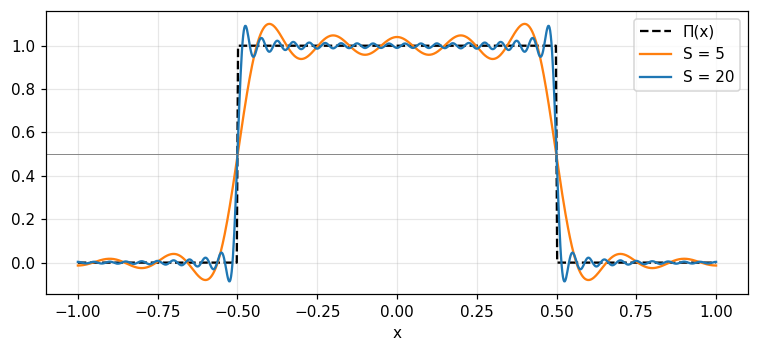

In [3]:
xx = np.linspace(-1, 1, 1001)
plt.figure(figsize=(7, 3.3))
plt.plot(xx, np.where(np.abs(xx) < 0.5 - 1e-12, 1.0, np.where(np.abs(np.abs(xx) - 0.5) <= 1e-12, 0.5, 0.0)), "k--", label="Π(x)")
for S, c in ((5, "tab:orange"), (20, "tab:blue")):
    plt.plot(xx, inv_si(xx, S), color=c, label=f"S = {S}")
plt.axhline(0.5, color="gray", lw=0.6); plt.xlabel("x"); plt.legend()
plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Tích phân số trùng công thức đóng: Gauss cho 0.4559 và sech cho 0.3985 tại $s=0.5$, $\Pi$ cho 0.6366 và 0 tại $s=0.5$ và $s=2$, $\Lambda$ cho 0.4053. Hàm nhân quả $e^{-x}H(x)$ tại $s=0.1$ có độ lớn 0.8467 và pha -32.14 độ. Hai lần DFT trả về dãy đảo (lệch 1.8e-14) bằng cả FFT lẫn ma trận tự dựng, và bốn lần trả về đúng dãy gốc (lệch 5.4e-16). Tại chỗ nhảy, biến đổi ngược cắt ở $S=5,20,100$ cho 0.4899, 0.4975, 0.4995, tiến về 0.5; bên trong xung được 0.9973, bên ngoài được 0.0007.

## 2. Biến đổi trong giới hạn
🎯 **Phương pháp này trả lời câu hỏi gì?** Khi nhân một hàm tuần hoàn hoặc hàm dấu với thừa số tắt dần rồi cho hệ số về 0, dãy biến đổi tiến về đâu? Ta tính đỉnh, độ rộng và diện tích bằng hai cách (quy tắc hình thang và FFT), và so hàm dấu với công thức đóng.

In [4]:
dx = 0.002
xg = np.arange(-150, 150, dx)
assert abs(xg[len(xg)//2]) < 1e-9
sk_all = np.fft.fftshift(np.fft.fftfreq(len(xg), dx)); ds = sk_all[1] - sk_all[0]
Fdict = {}
for tag, al in (("a1", 1.0), ("a01", 0.1), ("a001", 0.01)):
    g = np.exp(-al*xg**2)*np.cos(2*np.pi*5*xg)
    F5_trap = trap(g*np.cos(2*np.pi*5*xg), xg)                                  # cách A: quy tắc hình thang
    F5_exact = 0.5*np.sqrt(np.pi/al)
    Fk = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(g))).real*dx                 # cách B: FFT cả đoạn
    i5 = np.argmin(np.abs(sk_all - 5))
    assert abs(F5_trap - F5_exact)/F5_exact < 1e-6 and abs(Fk[i5] - F5_exact)/F5_exact < 1e-6
    m = (sk_all > 3) & (sk_all < 7)
    area = Fk[m].sum()*ds
    width = np.sqrt(np.sum((sk_all[m] - 5)**2*Fk[m])/np.sum(Fk[m]))
    assert abs(area - 0.5) < 5e-3 and abs(width - np.sqrt(al)/(np.pi*np.sqrt(2)))/width < 0.02
    report(f"peak_{tag}", F5_trap, ".4f"); report(f"width_{tag}", width, ".4f")
    m2 = (sk_all > 3.5) & (sk_all < 6.5); Fdict[tag] = (sk_all[m2], Fk[m2])
report("area_peak", area, ".4f")

# Hàm dấu: sgn(x)·exp(−α|x|) tại s = 0.5
def sgn_ft(al, s):
    return -2j*integrate.quad(lambda x: np.exp(-al*x), 0, np.inf, weight="sin", wvar=2*np.pi*s)[0]
closed = lambda al, s: -1j*4*np.pi*s/(al**2 + 4*np.pi**2*s**2)
for al, tag in ((0.1, "a01"), (0.01, "a001"), (0.001, "a0001")):
    assert abs(sgn_ft(al, 0.5) - closed(al, 0.5)) < 1e-9
    report(f"sgn_{tag}", sgn_ft(al, 0.5).imag, ".4f")
report("sgn_limit", (-1j/(np.pi*0.5)).imag, ".4f")

▸ peak_a1 = 0.8862
▸ width_a1 = 0.2251
▸ peak_a01 = 2.8025
▸ width_a01 = 0.0712
▸ peak_a001 = 8.8623
▸ width_a001 = 0.0225
▸ area_peak = 0.5
▸ sgn_a01 = -0.636
▸ sgn_a001 = -0.6366
▸ sgn_a0001 = -0.6366
▸ sgn_limit = -0.6366


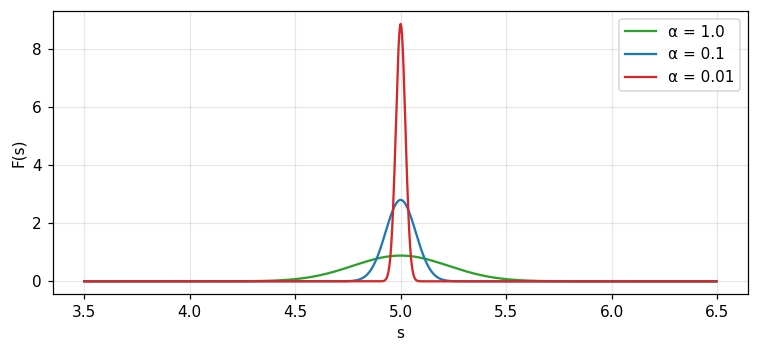

In [5]:
plt.figure(figsize=(7, 3.3))
for tag, al, c in (("a1", 1.0, "tab:green"), ("a01", 0.1, "tab:blue"), ("a001", 0.01, "tab:red")):
    plt.plot(Fdict[tag][0], Fdict[tag][1], color=c, label=f"α = {al}")
plt.xlabel("s"); plt.ylabel("F(s)"); plt.legend()
plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Chiều cao đỉnh 0.8862, 2.8025, 8.8623 tăng như $\tfrac12\sqrt{\pi/\alpha}$, độ rộng co lại 0.2251, 0.0712, 0.0225, còn diện tích luôn 0.5: dãy không hội tụ từng điểm nhưng định nghĩa một hàm suy rộng (cặp xung). Với hàm dấu, phần ảo -0.636, -0.6366, -0.6366 tiến về -0.6366, đúng $-1/(\pi s)$ của bài tập 3.

## 3. Chẵn, lẻ và bảng đối xứng
🎯 **Phương pháp này trả lời câu hỏi gì?** Tách hàm thành phần chẵn và lẻ như thế nào, thành phần nào phụ thuộc gốc, và bảng đối xứng của Bracewell có đúng với DFT không? Ta kiểm bằng công thức giải tích, bằng tích phân số năng lượng, và bằng DFT của các dãy có đối xứng dựng sẵn.

In [6]:
xg2 = np.linspace(-6, 6, 12001)
H = np.where(xg2 > 1e-12, 1.0, np.where(np.abs(xg2) <= 1e-12, 0.5, 0.0))
f = np.exp(-xg2)*H
ev, od = 0.5*(f + f[::-1]), 0.5*(f - f[::-1])
assert np.allclose(ev, 0.5*np.exp(-np.abs(xg2))) and np.allclose(od, 0.5*np.sign(xg2)*np.exp(-np.abs(xg2)))
i1, im1 = np.argmin(np.abs(xg2 - 1)), np.argmin(np.abs(xg2 + 1))
report("ev1", ev[i1], ".4f"); report("od1", od[i1], ".4f"); report("od_m1", od[im1], ".4f")
fe = np.exp(xg2)
assert np.allclose(0.5*(fe + fe[::-1]), np.cosh(xg2)) and np.allclose(0.5*(fe - fe[::-1]), np.sinh(xg2))
report("cosh1", np.cosh(1.0), ".4f"); report("sinh1", np.sinh(1.0), ".4f")

# Bài tập 17: tổng năng lượng chẵn và lẻ không phụ thuộc gốc
xg3 = np.linspace(-15, 15, 300001)
for a_, tag in ((0, "a0"), (0.5, "a05"), (1, "a1"), (2, "a2")):
    g_, gm_ = np.exp(-(xg3 - a_)**2), np.exp(-(-xg3 - a_)**2)
    ee, oo = trap((0.5*(g_ + gm_))**2, xg3), trap((0.5*(g_ - gm_))**2, xg3)
    assert abs(ee + oo - np.sqrt(np.pi/2)) < 1e-6
    report(f"ev_share_{tag}", ee/(ee + oo), ".4f")
report("energy_const", np.sqrt(np.pi/2), ".4f")

# Bảng đối xứng bằng DFT (sáu dòng)
Nq = 128; nq = np.arange(Nq); rv = (-nq) % Nq
rng = np.random.default_rng(7); a_r, b_r = rng.standard_normal(Nq), rng.standard_normal(Nq)
ev_ = lambda z: 0.5*(z + z[rv]); od_ = lambda z: 0.5*(z - z[rv])
isre = lambda z: np.max(np.abs(z.imag)) < 1e-10; isim = lambda z: np.max(np.abs(z.real)) < 1e-10
isev = lambda z: np.allclose(z, z[rv]); isod = lambda z: np.allclose(z, -z[rv])
cases = [(ev_(a_r), lambda F_: isre(F_) and isev(F_)), (od_(a_r), lambda F_: isim(F_) and isod(F_)),
         (1j*ev_(b_r), lambda F_: isim(F_) and isev(F_)), (1j*od_(b_r), lambda F_: isre(F_) and isod(F_)),
         (ev_(a_r) + 1j*od_(b_r), isre), (od_(a_r) + 1j*ev_(b_r), isim)]
Wq = np.exp(-2j*np.pi*np.outer(nq, nq)/Nq)
assert np.allclose(Wq @ cases[4][0], np.fft.fft(cases[4][0]))     # đối chiếu với ma trận DFT
ok = sum(bool(chk(np.fft.fft(v_))) for v_, chk in cases)
assert ok == len(cases)
report("sym_ok", ok, "d"); report("sym_total", len(cases), "d")

# Tín hiệu thực: chỉ cần nửa phổ
nr = np.arange(1000)
xr = np.cos(2*np.pi*13*nr/1000) + 0.5*np.sin(2*np.pi*77*nr/1000 + 0.4)
Xr = np.fft.fft(xr)
assert np.allclose(Xr[1:], np.conj(Xr[:0:-1]))
e_time = np.sum(xr**2)
e_half = (abs(Xr[0])**2 + 2*np.sum(abs(Xr[1:500])**2) + abs(Xr[500])**2)/1000
assert abs(e_time - e_half) < 1e-9
report("herm_full", len(Xr), "d"); report("herm_half", len(np.fft.rfft(xr)), "d"); report("herm_energy", e_time, ".4f")

▸ ev1 = 0.1839
▸ od1 = 0.1839
▸ od_m1 = -0.1839
▸ cosh1 = 1.5431
▸ sinh1 = 1.1752
▸ ev_share_a0 = 1
▸ ev_share_a05 = 0.8033
▸ ev_share_a1 = 0.5677
▸ ev_share_a2 = 0.5002
▸ energy_const = 1.2533
▸ sym_ok = 6
▸ sym_total = 6
▸ herm_full = 1000
▸ herm_half = 501
▸ herm_energy = 625


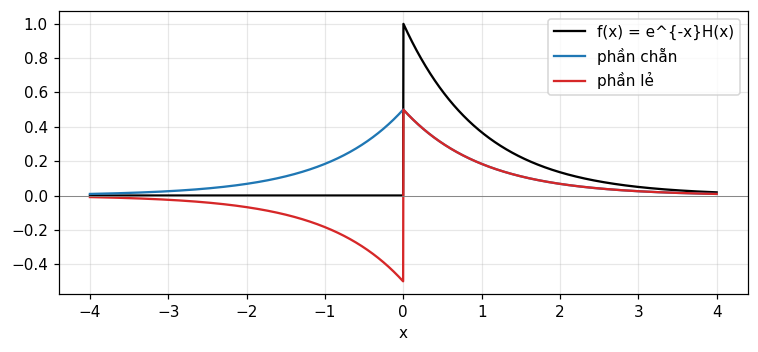

In [7]:
xp = np.linspace(-4, 4, 4001)
Hp = np.where(xp > 1e-12, 1.0, np.where(np.abs(xp) <= 1e-12, 0.5, 0.0)); fp = np.exp(-xp)*Hp
plt.figure(figsize=(7, 3.3))
plt.plot(xp, fp, "k", label="f(x) = e^{-x}H(x)")
plt.plot(xp, 0.5*(fp + fp[::-1]), "tab:blue", label=("phần chẵn"))
plt.plot(xp, 0.5*(fp - fp[::-1]), "tab:red", label=("phần lẻ"))
plt.axhline(0, color="gray", lw=0.6); plt.xlabel("x"); plt.legend()
plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Với $e^{-x}H(x)$, phần chẵn và phần lẻ tại $x=1$ là 0.1839 và 0.1839, tại $x=-1$ phần lẻ đổi dấu thành -0.1839. Với $e^x$ ta được $\cosh 1$ = 1.5431 và $\sinh 1$ = 1.1752. Tổng năng lượng chẵn và lẻ của $e^{-(x-a)^2}$ luôn là 1.2533 dù dịch gốc, trong khi phần chẵn chiếm 1, 0.8033, 0.5677, 0.5002 khi $a=0,0.5,1,2$. DFT thỏa 6 trên 6 dòng bảng đối xứng. Tín hiệu thực có 1000 hệ số nhưng chỉ 501 độc lập, và năng lượng 625 phục hồi đủ từ nửa phổ.

## 4. Liên hợp phức, biến đổi cosin và sin
🎯 **Phương pháp này trả lời câu hỏi gì?** Bảng tám dòng về liên hợp phức có đúng không, và với hàm nhân quả $e^{-x}H(x)$, biến đổi Fourier có đúng bằng $\tfrac12F_c-\tfrac12iF_s$ không? Ta kiểm bảng bằng DFT và các biến đổi cosin và sin bằng tích phân số so với công thức đóng.

In [8]:
fz = a_r + 1j*b_r
Fz = np.fft.fft(fz); cj = np.conj
rows = [(np.fft.fft(cj(fz)), cj(Fz)[rv]), (np.fft.fft(cj(fz)[rv]), cj(Fz)), (np.fft.fft(fz[rv]), Fz[rv]),
        (np.fft.fft(2*fz.real), Fz + cj(Fz)[rv]), (np.fft.fft(2j*fz.imag), Fz - cj(Fz)[rv]),
        (np.fft.fft(fz + cj(fz)[rv]), 2*Fz.real), (np.fft.fft(fz - cj(fz)[rv]), 2j*Fz.imag)]
conj_ok = sum(bool(np.allclose(l_, r_)) for l_, r_ in rows)
assert conj_ok == 7
report("conj_ok", conj_ok, "d")

s0 = 0.2                                                          # biến đổi cosin và sin của e^{-x}
Fc = 2*integrate.quad(lambda x: np.exp(-x), 0, np.inf, weight="cos", wvar=2*np.pi*s0)[0]
Fs = 2*integrate.quad(lambda x: np.exp(-x), 0, np.inf, weight="sin", wvar=2*np.pi*s0)[0]
Fc_ex, Fs_ex = 2/(1 + 4*np.pi**2*s0**2), 2*(2*np.pi*s0)/(1 + 4*np.pi**2*s0**2)
assert abs(Fc - Fc_ex) < 1e-9 and abs(Fs - Fs_ex) < 1e-9
F_caus = 1/(1 + 2j*np.pi*s0)
assert abs(0.5*Fc - 0.5j*Fs - F_caus) < 1e-9                       # F = ½Fc − ½iFs
F_even = ft_support(lambda x: np.exp(-abs(x)), -40, 40, s0, [0]).real
assert abs(F_even - Fc_ex) < 1e-8                                  # biến đổi Fourier của mở rộng chẵn = Fc
f1 = 2*integrate.quad(lambda s: 2/(1 + 4*np.pi**2*s**2), 0, np.inf, weight="cos", wvar=2*np.pi*1.0)[0]
assert abs(f1 - np.exp(-1)) < 1e-6                                 # tự nghịch đảo: thu lại f(1)
report("fc_02", Fc, ".4f"); report("fs_02", Fs, ".4f")
report("f_re_02", F_caus.real, ".4f"); report("f_im_02", F_caus.imag, ".4f")
report("f1_rec", f1, ".4f")

▸ conj_ok = 7
▸ fc_02 = 0.7755
▸ fs_02 = 0.9745
▸ f_re_02 = 0.3877
▸ f_im_02 = -0.4872
▸ f1_rec = 0.3679


#### 📤 Đầu ra thật
Cả 7 trên 7 quan hệ không tầm thường của bảng liên hợp đều đúng. Với $e^{-x}$ tại $s=0.2$: $F_c$ = 0.7755, $F_s$ = 0.9745, nên $F$ có phần thực 0.3877 và phần ảo -0.4872, đúng $\tfrac12F_c-\tfrac12iF_s$ và đúng $1/(1+i2\pi s)$. Biến đổi Fourier của mở rộng chẵn $e^{-|x|}$ cho 0.7755, và phép cosin ngược thu lại $f(1)$ = 0.3679, đúng $e^{-1}$: biến đổi cosin tự nghịch đảo.

## 5. Ba cách hình dung tích phân Fourier
🎯 **Phương pháp này trả lời câu hỏi gì?** Vì sao $F(s)$ nhỏ ở tần số cao, $F(0)$ là gì, và xoắn ốc trên mặt phẳng phức biểu diễn $F(s)$ ra sao? Ta tính diện tích dưới $f\cos2\pi sx$ và tích phân tích lũy trên mặt phẳng phức, mỗi thứ bằng hai cách.

In [9]:
fg = lambda x: np.exp(-np.pi*x**2)
area_low = ft_support(fg, -8, 8, 0.25).real; area_high = ft_support(fg, -8, 8, 2.0).real
assert abs(area_low - np.exp(-np.pi*0.25**2)) < 1e-9 and abs(area_high - np.exp(-4*np.pi)) < 1e-9
assert abs(ft_support(fg, -8, 8, 0.0).real - 1) < 1e-9             # F(0) = ∫ f
report("area_low", area_low, ".4f"); report("area_high", area_high, ".2e")

def locus(s, X=15.0, n=200001):                                     # tích phân tích lũy ∫_0^X e^{-x}e^{-i2πsx}dx
    x = np.linspace(0, X, n); w = np.exp(-x)*np.exp(-2j*np.pi*s*x)
    return x, np.concatenate([[0], np.cumsum((w[1:] + w[:-1])/2*np.diff(x))])
loci = {}
for s_, tag in ((0.1, "01"), (0.5, "05")):
    x_, cum = locus(s_); exact = 1/(1 + 2j*np.pi*s_)
    assert abs(cum[-1] - exact) < 1e-6
    loci[tag] = cum; report(f"spiral_abs_{tag}", abs(exact), ".4f")

▸ area_low = 0.8217
▸ area_high = 3.49e-06
▸ spiral_abs_01 = 0.8467
▸ spiral_abs_05 = 0.3033


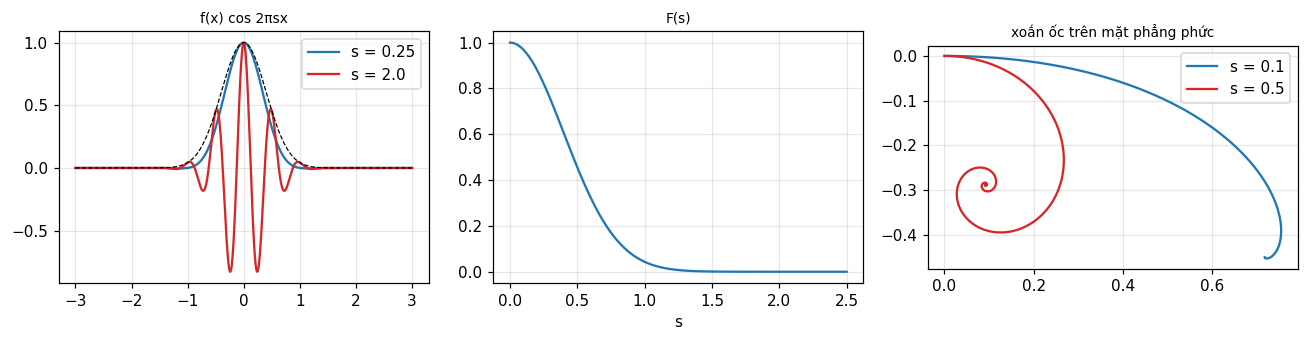

In [10]:
xs_ = np.linspace(-3, 3, 1201)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
for s_, c in ((0.25, "tab:blue"), (2.0, "tab:red")):
    ax[0].plot(xs_, fg(xs_)*np.cos(2*np.pi*s_*xs_), color=c, label=f"s = {s_}")
ax[0].plot(xs_, fg(xs_), "k--", lw=0.8); ax[0].legend(); ax[0].set_title("f(x) cos 2πsx", fontsize=9)
ss = np.linspace(0, 2.5, 400); ax[1].plot(ss, np.exp(-np.pi*ss**2)); ax[1].set_title("F(s)", fontsize=9); ax[1].set_xlabel("s")
for tag, c in (("01", "tab:blue"), ("05", "tab:red")):
    ax[2].plot(loci[tag].real, loci[tag].imag, color=c, label=f"s = {int(tag)/10}")
ax[2].set_aspect("equal"); ax[2].legend(); ax[2].set_title("xoắn ốc trên mặt phẳng phức", fontsize=9)
plt.tight_layout(); plt.show()

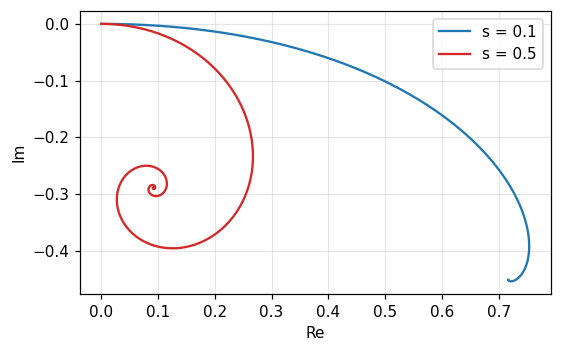

In [11]:
xs2 = np.linspace(-3, 3, 1201)
plt.figure(figsize=(5.5, 3.3))
for s_, c in ((0.1, "tab:blue"), (0.5, "tab:red")):
    x_, cum = locus(s_, 12, 4001)
    plt.plot(cum.real, cum.imag, color=c, label=f"s = {s_}")
plt.gca().set_aspect("equal"); plt.legend(); plt.xlabel("Re"); plt.ylabel("Im")
plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Với Gauss, diện tích dưới $f\cos2\pi sx$ là 0.8217 tại $s=0.25$ nhưng chỉ 3.49e-06 tại $s=2$: dao động nhanh làm các nửa chu kỳ dương và âm triệt tiêu, nên $F(s)\to0$ khi $s\to\infty$, còn $F(0)=\int f$. Xoắn ốc của $e^{-x}H(x)$ kết thúc ở vector có độ dài 0.8467 khi $s=0.1$ và 0.3033 khi $s=0.5$; tích phân tích lũy trùng công thức đóng $1/(1+i2\pi s)$.